# Final Assignment - Part 1

### Assignment Instructions

#### Part 1   |   Standard Difficulty Level

In this first part, you will be working with a datasets containing information of over 20k Software Professionals with different variables like:

- the `Rating` of the company given by the employee,
- the `Company Name`,
- the `Job Title` of the employee,
- the employee `Salary` (in Indian Rupee ₹),
- the number of `Salaries Reported`,
- the `Location` of the company,
- the `Employment Status` and
- the category of the `Job Roles`

The dataset name is `Software Professionals Salary.csv` and you will find it in the `data` folder of this repository. At [this link](https://www.kaggle.com/datasets/iamsouravbanerjee/software-professional-salaries-2022?search=salary) you can find the source of the data (Kaggle) as well as more information on its composition.

**Setup:** Import the necessary libraries and load the .csv file to a DataFrame named `sps`. Check that all columns have the correct data type.

In [2]:
import pandas as pd

sps = pd.read_csv("data/Software Professionals Salary.csv")
sps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


1. What is the shape (rows, cols) of the `sps` DataFrame?

In [5]:
sps.shape

(22770, 8)

2. How many unique `Job Roles` are there in the dataset?

In [4]:
sps["Job Roles"].nunique()

11

3. How many unique `Job Title` are there for the "Python" `Job Role`?

In [3]:
python_role = sps[sps['Job Roles'] == 'Python']
python_role["Job Title"].nunique()

102

4. Of the `Company Name`s that are listed in the DataFrame, **how many** have a "Python" `Job Role` with a `Job Title` containing the **substring** "Analyst"?

In [6]:
sps[(sps['Job Roles'] == 'Python') & (sps['Job Title'].str.contains("Analyst"))]['Company Name'].nunique()

3

5. Which `Company Name` has the highest number of `Salaries Reported` (across all `Job Title`s)?

In [7]:
nSalariesReported = sps.groupby('Company Name')['Salaries Reported'].agg(['sum'])
print(nSalariesReported.sort_values('sum').tail(1))

               sum
Company Name      
Amazon        2636


6. Given the `Company Name` you found at the previous question, how many `Location`s is this company present in?

In [8]:
sps[sps['Company Name'] == 'Amazon'].nunique()['Location']

np.int64(9)

7. As you may have noticed, the `Salary` is reported in Indian Rupees (ISO code: INR). Using the [Open Access Endpoint](https://www.exchangerate-api.com/docs/free) (no API Key required) of the ExchangeRate-API service, create a new column named `Salary USD` containing the salary-equivalent in USD and round the result to zero decimals. What is the conversion rate between USD-INR at the time of your execution? *Note: of course, this result will change in time*

In [10]:
import requests

url = 'https://open.er-api.com/v6/latest/USD'

conversion_rate = requests.get(url).json()['rates']['INR']
sps['Salary USD'] = round(sps['Salary'] / conversion_rate, 2)

8. What is the average `Salary USD` for the "Python" `Job Role`?

In [11]:
sps[sps['Job Roles'] == 'Python']['Salary USD'].mean()

np.float64(5212.288965153116)

9. Which `Company Name` has the highest **average** `Salary USD` across all `Job Title`s?

In [12]:
max_salary = sps.groupby('Company Name').mean(numeric_only=True)
max_salary['Salary USD'].sort_values(ascending=False)

,Salary USD
Company Name,
Thapar University,965193.49
Digital Raju,105098.85
FFF Enterprises,105098.85
Gaana Lyrics Point.com,104026.41
GGH Heavy Industries,102953.97
...,...
Excel Engineering Services,128.69
Acmatics Technologies,128.69
Scholify,128.69


10. Create a Plot that shows the **relationship** between the average `Salary USD` and the average `Rating` for each `Company Name`. Do you see any anomaly in the plot? Which is the `Company Name` that is causing this oddity?

The max USD Salary is 965193.49 and comes from 18635    Thapar University
Name: Company Name, dtype: object


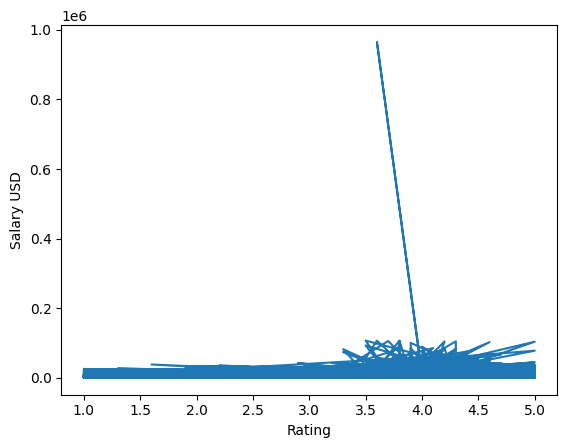

In [23]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

plt.plot('Rating', 'Salary USD', data=sps)
plt.xlabel('Rating')
plt.ylabel('Salary USD')

#judging from the graph theres an anomaly with a rating of 3.6
max_usd_salary = sps['Salary USD'].max()
anomalous_company = sps[sps['Salary USD'] == max_usd_salary]

print(f'The max USD Salary is {max_usd_salary} and comes from {anomalous_company['Company Name']}')